In [1]:
# DecesionTree
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder


In [2]:
# read the veteran dataset
df = pd.read_csv('PreProcesseddataset_ifn580_262_v1.csv')

# show all columns information
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  Int64
 1   passanger             12684 non-null  Int64
 2   weather               12684 non-null  Int64
 3   temperature           12684 non-null  Int64
 4   time                  12684 non-null  Int64
 5   coupon                12684 non-null  Int64
 6   expiration            12684 non-null  Int64
 7   gender                12684 non-null  Int64
 8   age                   12684 non-null  Int64
 9   maritalStatus         12684 non-null  Int64
 10  has_children          12684 non-null  Int64
 11  education             12684 non-null  Int64
 12  occupation            12684 non-null  Int64
 13  income                12684 non-null  Int64
 14  Bar                   12684 non-null  Int64
 15  CoffeeHouse           12684 non-null  Int64
 16  Carr

In [5]:
# our goal is is_accepted
# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
y = df["is_accepted"].values
# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
# axis=1 is used to drop the column, instead of the row.
X = df.drop(['is_accepted'], axis=1)
# Pull out the column names before grabbing the feature array, we will need it later
feature_names = X.columns
# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
X = X.values

In [7]:
from sklearn.model_selection import train_test_split
# Create a 30% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
random_state = 10
test_set_size = 0.3 # 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_set_size,
stratify=y, random_state=random_state)
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 8878
Size of testing set: 3806


In [8]:
from sklearn.tree import DecisionTreeClassifier
# simple decision tree training
model = DecisionTreeClassifier(random_state=random_state)
model.fit(X_train, y_train)
#

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
print('*****Model parameters******\n', model.get_params(deep=True))
print('Number of leaves in the trained model:', model.get_n_leaves())

*****Model parameters******
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}
Number of leaves in the trained model: 2387


In [10]:
print("Training set accuracy:", model.score(X_train, y_train))

Training set accuracy: 0.9985357062401442


In [11]:
print("Testing set accuracy:", model.score(X_test, y_test))

Testing set accuracy: 0.6865475564897531


In [12]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 0 ... 0 1 0]


In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.65      0.64      1643
           1       0.73      0.71      0.72      2163

    accuracy                           0.69      3806
   macro avg       0.68      0.68      0.68      3806
weighted avg       0.69      0.69      0.69      3806



In [14]:
def display_feature_importances(model, feature_names, features_to_display=20): 
    # Grab feature importances from the model and feature name from the original X. 
    # We have to get the feature names from the original dataframe, because the featurearray does not include column titles. 
    importances = model.feature_importances_
    
    # Sort them out in descending order.
    indices = np.argsort(importances)
    indices = np.flip(indices, axis=0)
    
    # Limit to 20 features, you can leave this out to print out everything.
    indices = indices[:features_to_display]
    for i in indices:
        print(feature_names[i], ':', importances[i])
    print("Number of leaves:", model.get_n_leaves())
    
display_feature_importances(model, feature_names)

coupon : 0.11746302826158737
occupation : 0.08642431756527322
income : 0.06731003503510057
age : 0.06390383216871898
CoffeeHouse : 0.05600751443177855
time : 0.055321427318700586
Bar : 0.05487998595910649
CarryAway : 0.051652129519608764
RestaurantLessThan20 : 0.04893743065602246
education : 0.0476829298141425
Restaurant20To50 : 0.04079646735848118
passanger : 0.04070075343743321
destination : 0.03741003214872269
maritalStatus : 0.03661579310862626
temperature : 0.03426714316871467
expiration : 0.032868158870770166
direction_same : 0.025648507527443177
weather : 0.02485299038707558
gender : 0.023803194682038127
toCoupon_GEQ15min : 0.022719820670101577
Number of leaves: 2387


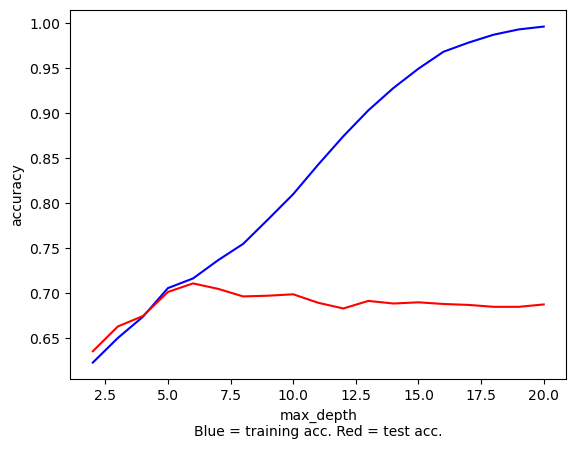

In [17]:
import matplotlib.pyplot as plt
# Check the model performance for max depth from 2-20, store into two lists that we can plot.
test_score = []
train_score = []
for max_depth in range(2, 21):
    temp_model = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    temp_model.fit(X_train, y_train)
    test_score.append(temp_model.score(X_test, y_test))
    train_score.append(temp_model.score(X_train, y_train))

# Plot max depth hyperparameter values vs training and test accuracy score.
plt.plot(range(2, 21), train_score, 'b', range(2, 21), test_score, 'r')
plt.xlabel('max_depth\nBlue = training acc. Red = test acc.')
plt.ylabel('accuracy')
plt.show()